In [11]:
# CÉLULA 1: Configuração e Carregamento dos Dados (Lote Parquet + CSV)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#NOTE: Subindo um nível para sair de 'notebooks/' e acessar 'data/'
RAIZ = Path().resolve().parent 
DIR_CAGED = RAIZ / "data" / "processed" / "caged"
#NOTE: O arquivo do INMET ainda está em formato CSV.
CAMINHO_CLIMA = RAIZ / "data" / "processed" / "clima" / "clima_rs_mensal.csv"

if not DIR_CAGED.exists():
    print(f"❌ Erro: O diretório {DIR_CAGED} não existe.")
else:
    arquivos_caged = list(DIR_CAGED.rglob("*tabela_3*.parquet"))
    
    if not arquivos_caged:
        print(f"⚠️ Alerta: Nenhum arquivo 'tabela_1' encontrado em {DIR_CAGED}")
    else:
        try:
            #NOTE: Leitura em lote dos arquivos Parquet do CAGED.
            df_caged = pd.concat([pd.read_parquet(f) for f in arquivos_caged], ignore_index=True)
            
            #NOTE: Leitura do arquivo CSV do INMET.
            df_clima = pd.read_csv(CAMINHO_CLIMA)
            
            print(f"✅ Dados carregados! CAGED: {df_caged.shape[0]} linhas | INMET: {df_clima.shape[0]} linhas")
        except Exception as e:
            print(f"❌ Erro no processamento: {e}")

✅ Dados carregados! CAGED: 12922 linhas | INMET: 36 linhas


In [12]:
# CÉLULA 2
#NOTE: Identificando as colunas e tratando 'competencia' do INMET.
cols = df_clima.columns.tolist()
print(f"🔍 Colunas do Clima: {cols}")

if 'competencia' in cols:
    #NOTE: Converte YYYYMM para colunas separadas de Ano e Mes.
    df_clima['Ano'] = df_clima['competencia'].astype(str).str[:4].astype(int)
    df_clima['Mes'] = df_clima['competencia'].astype(str).str[4:6].astype(int)
    print("✅ Colunas 'Ano' e 'Mes' extraídas de 'competencia'.")
else:
    col_data_list = [c for c in cols if 'data' in c.lower() or 'dt' in c.lower()]
    if col_data_list:
        col_data = col_data_list[0]
        df_clima[col_data] = pd.to_datetime(df_clima[col_data])
        df_clima['Ano'] = df_clima[col_data].dt.year
        df_clima['Mes'] = df_clima[col_data].dt.month

col_chuva = [c for c in cols if 'precipita' in c.lower() or 'chuva' in c.lower()][0]

#NOTE: Agregação mensal (caso haja mais de um registro por mês no clima).
df_clima_mensal = df_clima.groupby(['Ano', 'Mes'])[col_chuva].sum().reset_index()
df_clima_mensal.rename(columns={col_chuva: 'Chuva_Total_Mes'}, inplace=True)

print("🌧️ Dados climáticos agregados por mês.")
display(df_clima_mensal.head())

🔍 Colunas do Clima: ['competencia', 'precipitacao']
✅ Colunas 'Ano' e 'Mes' extraídas de 'competencia'.
🌧️ Dados climáticos agregados por mês.


,Ano,Mes,Chuva_Total_Mes
0,2023,1,3061.0
1,2023,2,3926.8
2,2023,3,5333.4
3,2023,4,2122.0
4,2023,5,6804.2


In [13]:
# CÉLULA 3: Tratamento do CAGED (Tabela 3) e Merge com Clima
import re

# Captura colunas de saldos mensais vigentes
colunas_saldos = [c for c in df_caged.columns if '_saldos' in c and 'acumulado' not in c and 'últimos' not in c]

meses_map = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4, 'maio': 5, 'mai': 5,
    'junho': 6, 'julho': 7, 'agosto': 8, 'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12
}

lista_frames = []

for col in colunas_saldos:
    match = re.search(r'([a-zç]+)(\d{4})', col)
    if match:
        mes_nome, ano_val = match.group(1), int(match.group(2))
        mes_val = meses_map.get(mes_nome)
        
        if mes_val:
            # CORREÇÃO: Utilizando as colunas reais da Tabela 3 ('uf', 'município')
            # Usamos get() ou uma checagem preventiva para evitar novos KeyErrors
            col_mun = 'município' if 'município' in df_caged.columns else 'municipio'
            
            temp_df = df_caged[['uf', col_mun, col]].copy()
            temp_df = temp_df.dropna(subset=[col]) 
            
            # Garante que lixo ou totais ocultos sejam removidos antes de empilhar
            temp_df = temp_df[~temp_df[col_mun].astype(str).str.contains('total|ignorado|subtotal', case=False, na=False)]
            
            temp_df['Ano'] = ano_val
            temp_df['Mes'] = mes_val
            temp_df.rename(columns={col: 'Saldo_Empregos', col_mun: 'Municipio', 'uf': 'UF'}, inplace=True)
            lista_frames.append(temp_df)

# Cria o DataFrame no formato longo (ainda por município)
df_caged_longo = pd.concat(lista_frames, ignore_index=True)

# Agrega os dados a nível ESTADUAL para que o merge por data bata 1:1 com o INMET
df_caged_mensal_rs = df_caged_longo.groupby(['Ano', 'Mes'])['Saldo_Empregos'].sum().reset_index()

# Realiza o Merge com o clima mensal consolidado
df_merged = pd.merge(df_caged_mensal_rs, df_clima_mensal, on=['Ano', 'Mes'], how='inner')
df_merged = df_merged.sort_values(['Ano', 'Mes']).reset_index(drop=True)

print(f"🔗 Merge concluído! Período detectado: {df_merged['Ano'].min()} até {df_merged['Ano'].max()}")
print(f"Formato final do Dataset unificado: {df_merged.shape[0]} meses agregados.")
display(df_merged.head(12))

🔗 Merge concluído! Período detectado: 2023 até 2025
Formato final do Dataset unificado: 25 meses agregados.


,Ano,Mes,Saldo_Empregos,Chuva_Total_Mes
0,2023,8,2561.0,3280.8
1,2023,9,1267.0,17467.0
2,2023,10,21532.0,11192.0
3,2023,12,-28832.0,7767.2
4,2024,2,25452.0,5092.6
5,2024,3,10490.0,6629.8
6,2024,4,13512.0,12054.8
7,2024,5,-22180.0,15924.8
8,2024,7,6690.0,2483.4
9,2024,8,10413.0,5160.2


In [14]:
# CÉLULA 4 - VERIFICAÇÃO
display(df_merged[df_merged['Ano'] == 2024].head())

,Ano,Mes,Saldo_Empregos,Chuva_Total_Mes
4,2024,2,25452.0,5092.6
5,2024,3,10490.0,6629.8
6,2024,4,13512.0,12054.8
7,2024,5,-22180.0,15924.8
8,2024,7,6690.0,2483.4


In [15]:
# CÉLULA 5: Cálculo da Correlação
if not df_merged.empty:
    # Agrupa por mês para consolidar o estado antes de calcular
    df_analise = df_merged.groupby(['Ano', 'Mes'])[['Saldo_Empregos', 'Chuva_Total_Mes']].sum().reset_index()
    
    corr_pearson = df_analise['Saldo_Empregos'].corr(df_analise['Chuva_Total_Mes'], method='pearson')
    corr_spearman = df_analise['Saldo_Empregos'].corr(df_analise['Chuva_Total_Mes'], method='spearman')
    
    print(f"📈 Coeficiente de Pearson (Linear): {corr_pearson:.4f}")
    print(f"📊 Coeficiente de Spearman (Postos/Choque): {corr_spearman:.4f}")
    
    print("\n💡 INTERPRETAÇÃO PARA O DOSSIÊ:")
    print(f"O Spearman é mais robusto para capturar o impacto do desastre de maio/2024.")

📈 Coeficiente de Pearson (Linear): -0.2617
📊 Coeficiente de Spearman (Postos/Choque): -0.1908

💡 INTERPRETAÇÃO PARA O DOSSIÊ:
O Spearman é mais robusto para capturar o impacto do desastre de maio/2024.


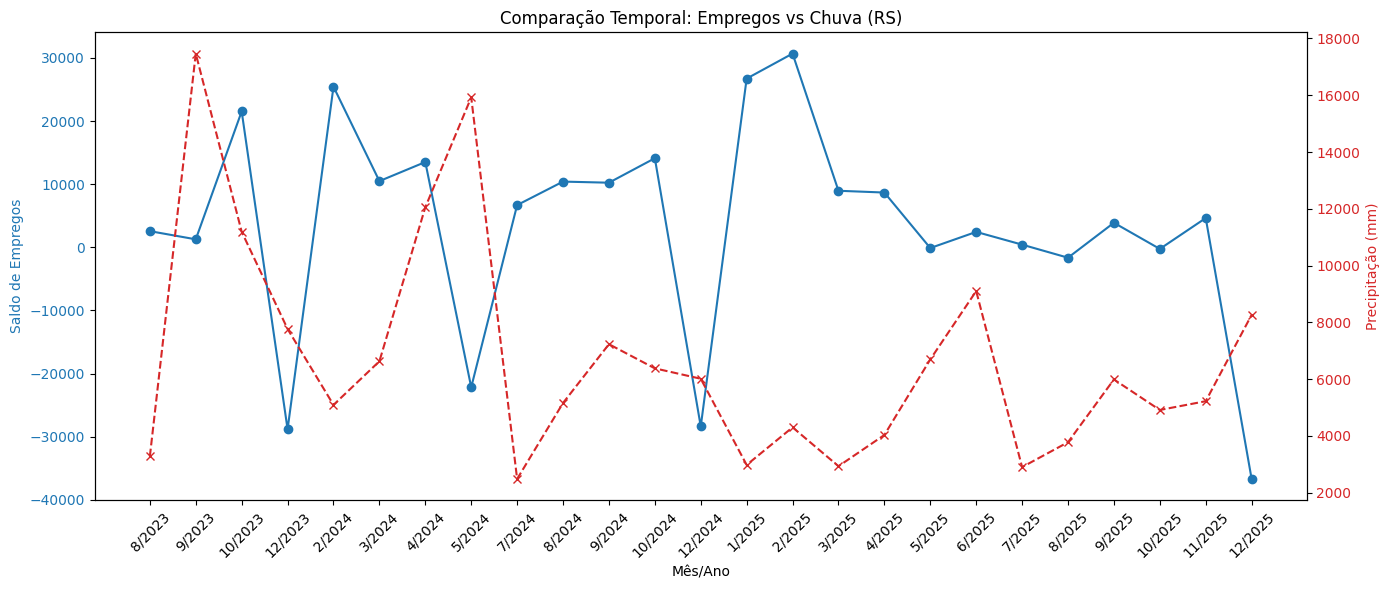

In [16]:
# CÉLULA 6
if not df_merged.empty:
    df_merged['Data_Ref'] = df_merged['Mes'].astype(str) + '/' + df_merged['Ano'].astype(str)
    
    df_plot = df_merged.groupby(['Ano', 'Mes', 'Data_Ref']).agg({
        'Saldo_Empregos': 'sum',
        'Chuva_Total_Mes': 'mean'
    }).reset_index().sort_values(['Ano', 'Mes'])

    fig, ax1 = plt.subplots(figsize=(14, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Mês/Ano')
    ax1.set_ylabel('Saldo de Empregos', color=color)
    ax1.plot(df_plot['Data_Ref'], df_plot['Saldo_Empregos'], color=color, marker='o', label='Saldo')
    ax1.tick_params(axis='y', labelcolor=color)
    plt.xticks(rotation=45)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Precipitação (mm)', color=color)
    ax2.plot(df_plot['Data_Ref'], df_plot['Chuva_Total_Mes'], color=color, linestyle='--', marker='x', label='Chuva')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Comparação Temporal: Empregos vs Chuva (RS)')
    fig.tight_layout()
    
    plt.savefig(RAIZ / "outputs" / "charts" / "evolucao_temporal_rs.png")
    plt.show()

In [17]:

# CÉLULA 7
df_agrupado = df_merged.groupby(['Ano', 'Mes']).agg({'Saldo_Empregos': 'sum', 'Chuva_Total_Mes': 'mean'}).reset_index()
df_agrupado = df_agrupado.sort_values(['Ano', 'Mes'])

# Desloca a chuva para correlacionar o impacto no futuro (Lag de 1 mês)
df_agrupado['Chuva_Mes_Anterior'] = df_agrupado['Chuva_Total_Mes'].shift(1)

corr_direta = df_agrupado['Chuva_Total_Mes'].corr(df_agrupado['Saldo_Empregos'], method='spearman')
corr_lag1 = df_agrupado['Chuva_Mes_Anterior'].corr(df_agrupado['Saldo_Empregos'], method='spearman')

print(f"📊 Correlação Imediata (Chuva Atual × Emprego Atual): {corr_direta:.4f}")
print(f"🕒 Correlação de Lag Time (Chuva do Mês Anterior × Emprego Atual): {corr_lag1:.4f}")

📊 Correlação Imediata (Chuva Atual × Emprego Atual): -0.1908
🕒 Correlação de Lag Time (Chuva do Mês Anterior × Emprego Atual): -0.0339


In [20]:
# CÉLULA 8: Exportação do Dataset Unificado para Relatórios Finais
caminho_final = RAIZ / "data" / "processed" / "caged_vs_clima_rs.csv"
df_merged.to_csv(caminho_final, index=False, encoding="utf-8-sig")

print(f"💾 Dataset consolidado salvo com sucesso em: {caminho_final}")
print("Pronto para ser referenciado no relatório final do projeto!")

💾 Dataset consolidado salvo com sucesso em: /home/lk1048/repositories/academic/estacio/ads-3-periodo/big-data/rs-impact/data/processed/caged_vs_clima_rs.csv
Pronto para ser referenciado no relatório final do projeto!


In [33]:
%%writefile ../src/analysis/analise_setorial.py
import os
import re
import glob
import pandas as pd
from pathlib import Path

# Configuração de caminhos baseada na estrutura do projeto rs-impact
RAIZ = Path(__file__).resolve().parents[2]
DIR_RAW_CAGED = RAIZ / "data" / "raw" / "caged"
DIR_OUTPUT = RAIZ / "data" / "processed" / "caged"

DIR_OUTPUT.mkdir(parents=True, exist_ok=True)

meses_map = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4, 'maio': 5,
    'junho': 6, 'julho': 7, 'agosto': 8, 'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12
}

def extrair_dados_setoriais():
    # Varre a pasta de forma recursiva para pegar os arquivos .xlsx dentro das subpastas de anos
    arquivos_brutos = list(DIR_RAW_CAGED.rglob("*"))
    arquivos_xlsx = [str(f) for f in arquivos_brutos if f.suffix.lower() in ['.xlsx', '.xls']]
    
    if not arquivos_xlsx:
        print(f"❌ Nenhum arquivo Excel encontrado recursivamente em: {DIR_RAW_CAGED}")
        return
    
    print(f"📂 Iniciando extração setorial de {len(arquivos_xlsx)} arquivos encontrados nas subpastas...")
    lista_final = []
    
    for caminho_arq in arquivos_xlsx:
        nome_arq = os.path.basename(caminho_arq).lower()
        
        # Captura o padrão de data de forma flexível
        match_data = re.search(r'([a-zç]+)(?:-de-|\s*|_|-)(\d{4})', nome_arq)
        if not match_data:
            continue
            
        mes_nome, ano_val = match_data.group(1), int(match_data.group(2))
        mes_val = meses_map.get(mes_nome)
        
        if not mes_val:
            continue
            
        try:
            xls = pd.ExcelFile(caminho_arq)
            aba_alvo = [s for s in xls.sheet_names if 'tabela 3' in s.lower() or 'tab3' in s.lower() or 'tab 3' in s.lower()]
            if not aba_alvo:
                continue
                
            df_raw = pd.read_excel(caminho_arq, sheet_name=aba_alvo[0], header=None)
            
            for idx, linha in df_raw.iterrows():
                linha_str = [str(val).strip().lower() for val in list(linha.values)]
                
                # Procura a linha que resume o total do Estado do RS
                if any('rio grande do sul' in s or s == '43' for s in linha_str):
                    saldos_setores = {
                        'Agropecuária': linha.iloc[7] if len(linha) > 7 else 0,
                        'Indústria': linha.iloc[11] if len(linha) > 11 else 0,
                        'Construção': linha.iloc[15] if len(linha) > 15 else 0,
                        'Comércio': linha.iloc[19] if len(linha) > 19 else 0,
                        'Serviços': linha.iloc[23] if len(linha) > 23 else 0
                    }
                    
                    for setor, saldo in saldos_setores.items():
                        try:
                            saldo_num = float(saldo)
                        except:
                            saldo_num = 0.0
                            
                        lista_final.append({
                            'Ano': ano_val,
                            'Mes': mes_val,
                            'Setor': setor,
                            'Saldo_Setorial': saldo_num
                        })
                    break
        except Exception as e:
            print(f"⚠️ Erro ao processar o arquivo {nome_arq}: {e}")
            
    if lista_final:
        df_resultado = pd.DataFrame(lista_final)
        caminho_salvamento = DIR_OUTPUT / "caged_setorial_rs.csv"
        df_resultado.to_csv(caminho_salvamento, index=False, encoding='utf-8-sig')
        print(f"✅ Painel setorial consolidado com sucesso em: {caminho_salvamento}")
    else:
        print("❌ Os arquivos foram achados, mas as linhas de dados do RS não foram identificadas.")

if __name__ == "__main__":
    extrair_dados_setoriais()

Overwriting ../src/analysis/analise_setorial.py


In [34]:
# CÉLULA 10: Processamento Setorial e Análise de Vulnerabilidade
import pandas as pd
from pathlib import Path

# 1. Executa o novo script isolado de análise setorial
print("⚙️ Executando extração de dados por atividade econômica...")
!python ../src/analysis/analise_setorial.py

# 2. Carrega o resultado setorial gerado
RAIZ = Path("..").resolve()
CAMINHO_SETORIAL = RAIZ / "data" / "processed" / "caged" / "caged_setorial_rs.csv"

if CAMINHO_SETORIAL.exists():
    df_setorial = pd.read_csv(CAMINHO_SETORIAL)
    
    # Cruza com a tabela do INMET que já está limpa na memória do notebook (df_clima_mensal)
    df_setorial_final = pd.merge(df_setorial, df_clima_mensal, on=['Ano', 'Mes'], how='inner')
    
    print("\n📊 BALANÇA DE EMPREGOS NO MÊS DE MAIO POR SETOR ECONÔMICO:")
    df_maio = df_setorial_final[df_setorial_final['Mes'] == 5]
    df_pivot_maio = df_maio.pivot(index='Setor', columns='Ano', values='Saldo_Setorial')
    display(df_pivot_maio)
    
    print("\n📊 COEFICIENTE DE SPEARMAN SETORIAL (Impacto Climático por Atividade):")
    resultados_setor = []
    for setor in df_setorial_final['Setor'].unique():
        df_sub = df_setorial_final[df_setorial_final['Setor'] == setor].sort_values(['Ano', 'Mes'])
        
        # Spearman calculado através do Rank das variáveis
        corr_spearman = df_sub['Saldo_Setorial'].rank().corr(df_sub['Chuva_Total_Mes'].rank(), method='pearson')
        resultados_setor.append({'Setor': setor, 'Spearman_Clima': corr_spearman})
        
    display(pd.DataFrame(resultados_setor))
else:
    print("❌ O arquivo setorial não foi gerado.")

⚙️ Executando extração de dados por atividade econômica...
📂 Iniciando extração setorial de 26 arquivos encontrados nas subpastas...
/home/lk1048/.venvs/bigdata/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/home/lk1048/.venvs/bigdata/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/home/lk1048/.venvs/bigdata/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/home/lk1048/.venvs/bigdata/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot pars

Ano,2024,2025
Setor,,
Agropecuária,-7.0,-0.884956
Comércio,0.0,0.000000
Construção,-8.0,-2.890173
Indústria,-1.0,-0.591716
Serviços,0.0,0.000000



📊 COEFICIENTE DE SPEARMAN SETORIAL (Impacto Climático por Atividade):


/home/lk1048/.venvs/bigdata/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/lk1048/.venvs/bigdata/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Setor,Spearman_Clima
0,Agropecuária,-0.301066
1,Indústria,0.190476
2,Construção,0.284594
3,Comércio,NaN
4,Serviços,NaN


In [36]:
import os
import pandas as pd
from pathlib import Path

# Garante o caminho absoluto independente de onde o notebook está rodando
RAIZ = Path("..").resolve()
DIR_RAW_CAGED = RAIZ / "data" / "raw" / "caged"

print(f"Buscando arquivos em: {DIR_RAW_CAGED}\n")

# Procura o arquivo de maio de 2024 de forma flexível
arquivos_maio = [f for f in DIR_RAW_CAGED.rglob("*") if "maio" in f.name.lower() and "2024" in f.name]

if arquivos_maio:
    arq_teste = arquivos_maio[0]
    print(f"🔍 Arquivo encontrado para teste: {arq_teste.relative_to(RAIZ)}")
    
    try:
        xls = pd.ExcelFile(arq_teste)
        aba_alvo = [s for s in xls.sheet_names if 'tabela 3' in s.lower() or 'tab 3' in s.lower() or 'tab3' in s.lower()]
        
        if aba_alvo:
            print(f"📖 Lendo a aba: '{aba_alvo[0]}'")
            df = pd.read_excel(arq_teste, sheet_name=aba_alvo[0], header=None)
            
            print("\n--- Linhas encontradas que contêm o RS ou código 43 ---")
            encontrou = False
            for idx, linha in df.iterrows():
                linha_str = [str(val).strip().lower() for val in list(linha.values)]
                
                if any('rio grande do sul' in s or s == '43' for s in linha_str):
                    encontrou = True
                    print(f"\n📍 Linha ID (Índice do Pandas): {idx}")
                    for col_idx, val in enumerate(linha.values):
                        if pd.notna(val):
                            print(f"  Coluna {col_idx}: {val}")
            
            if not encontrou:
                print("❌ Nenhuma linha com 'Rio Grande do Sul' ou '43' foi identificada nesta aba.")
                print("Primeiras linhas da planilha para inspeção visual:")
                display(df.topic(10) if hasattr(df, 'topic') else df.head(10))
        else:
            print(f"❌ Abas disponíveis no arquivo: {xls.sheet_names}")
            print("Nenhuma aba correspondente à 'Tabela 3' foi encontrada.")
            
    except Exception as e:
        print(f"💥 Erro ao ler o arquivo: {e}")
else:
    print("❌ Nenhum arquivo de maio de 2024 foi localizado nas subpastas.")

Buscando arquivos em: /home/lk1048/repositories/academic/estacio/ads-3-periodo/big-data/rs-impact/data/raw/caged

🔍 Arquivo encontrado para teste: data/raw/caged/2024/5-tabelas-maio-2024.xlsx
📖 Lendo a aba: 'Tabela 3'


/home/lk1048/.venvs/bigdata/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")



--- Linhas encontradas que contêm o RS ou código 43 ---

📍 Linha ID (Índice do Pandas): 38
  Coluna 1: RO
  Coluna 2: 110090
  Coluna 3: Ro-Castanheiras
  Coluna 4: 346
  Coluna 5: 3
  Coluna 6: 10
  Coluna 7: -7
  Coluna 8: -1.9830028328611897
  Coluna 9: 82
  Coluna 10: 83
  Coluna 11: -1
  Coluna 12: -0.2881844380403458
  Coluna 13: 35
  Coluna 14: 43
  Coluna 15: -8
  Coluna 16: -2.2598870056497176

📍 Linha ID (Índice do Pandas): 91
  Coluna 1: AM
  Coluna 2: 130068
  Coluna 3: Am-Boa Vista do Ramos
  Coluna 4: 100
  Coluna 5: 0
  Coluna 6: 4
  Coluna 7: -4
  Coluna 8: -3.8461538461538463
  Coluna 9: 43
  Coluna 10: 28
  Coluna 11: 15
  Coluna 12: 17.647058823529413
  Coluna 13: 9
  Coluna 14: 16
  Coluna 15: -7
  Coluna 16: -6.5420560747663545

📍 Linha ID (Índice do Pandas): 106
  Coluna 1: AM
  Coluna 2: 130180
  Coluna 3: Am-Ipixuna
  Coluna 4: 43
  Coluna 5: 0
  Coluna 6: 0
  Coluna 7: 0
  Coluna 8: 0
  Coluna 9: 10
  Coluna 10: 5
  Coluna 11: 5
  Coluna 12: 13.157894736842104